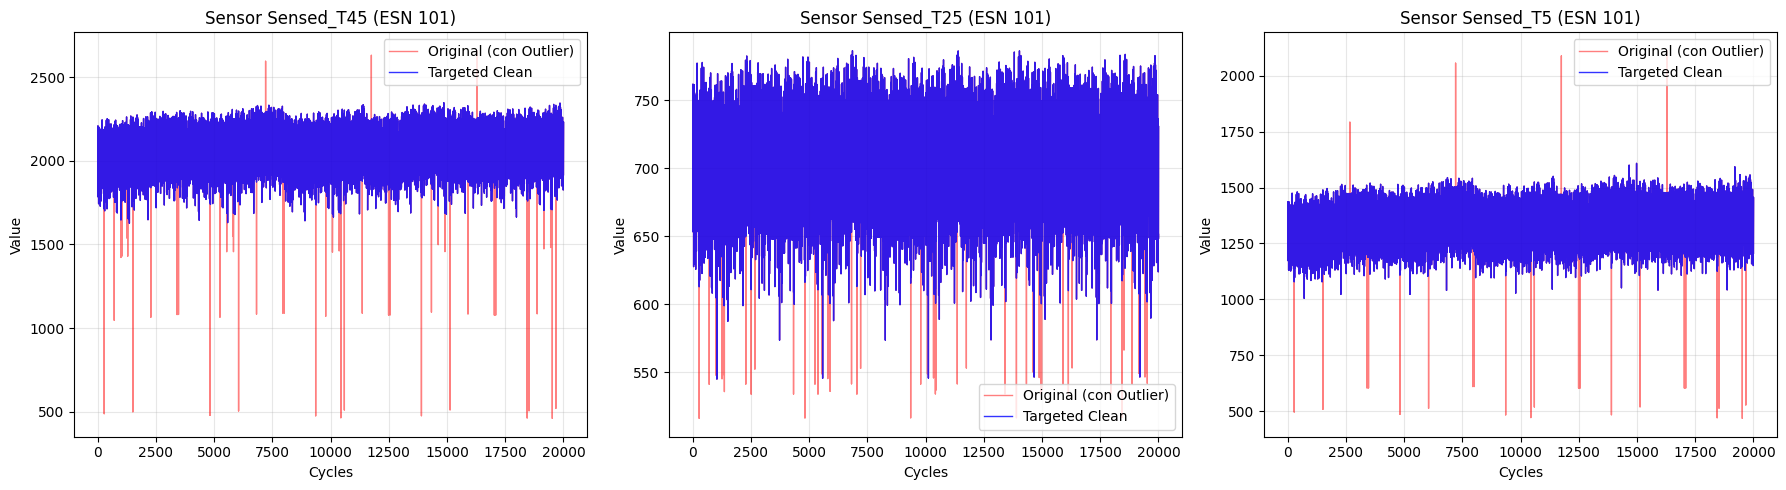

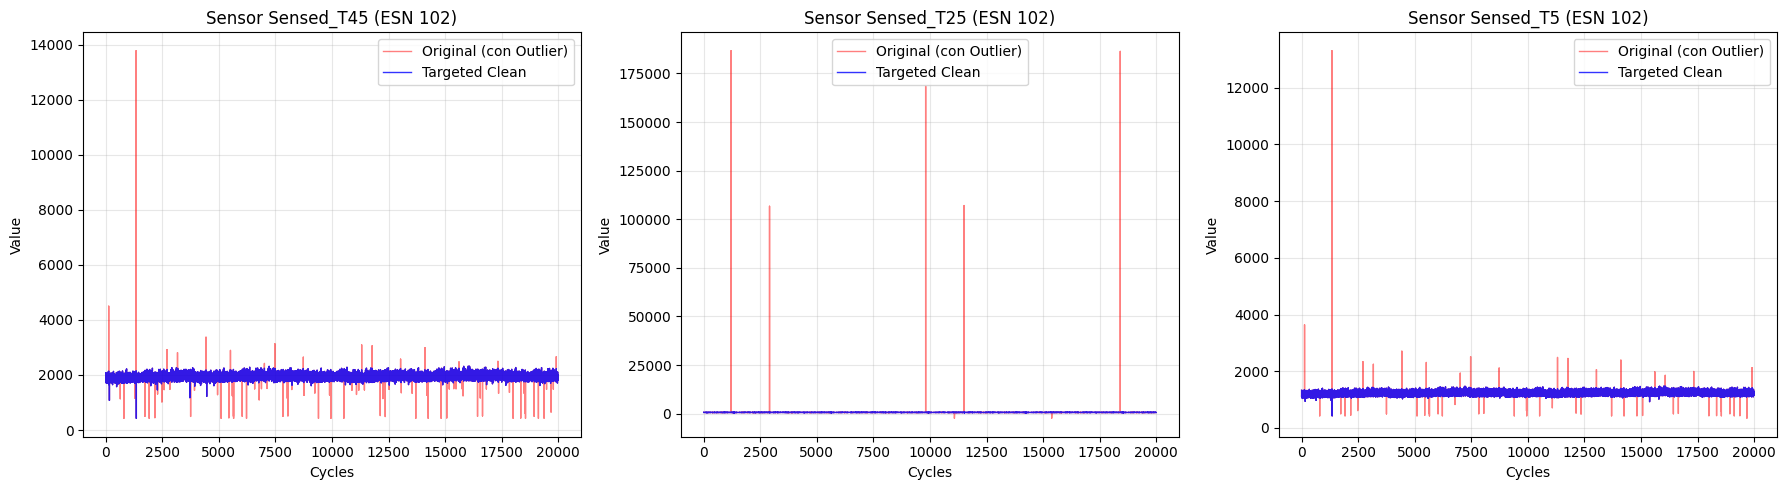

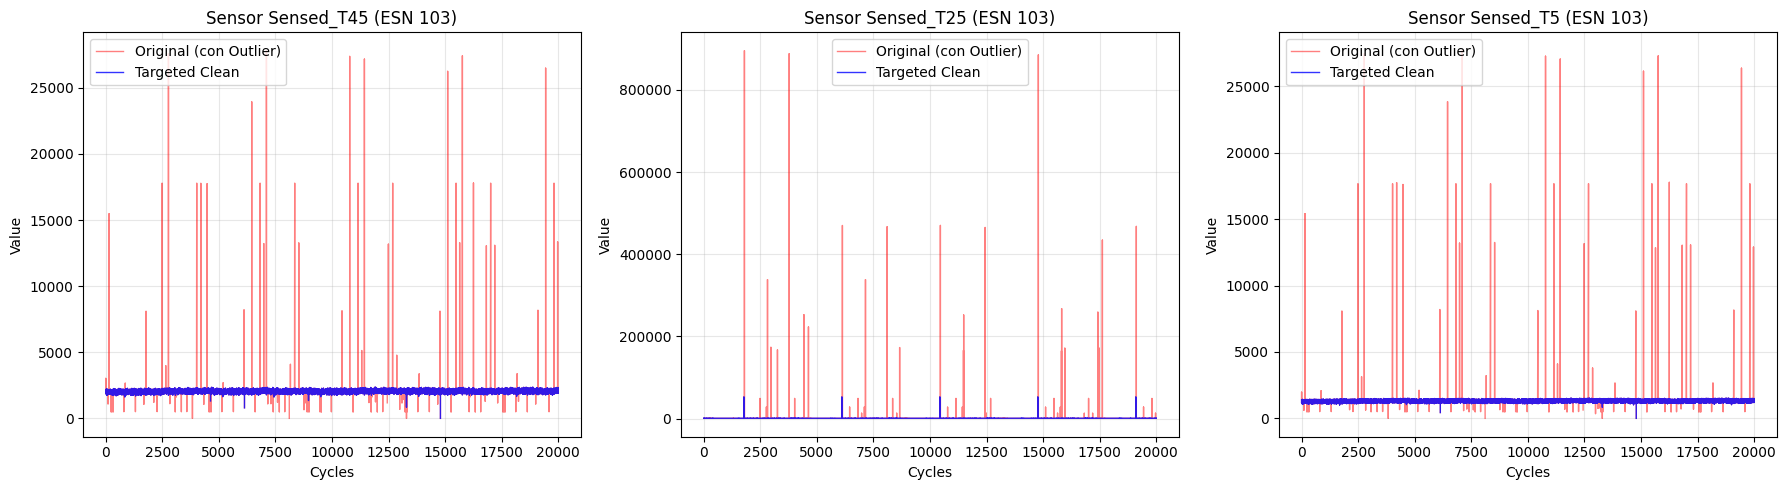

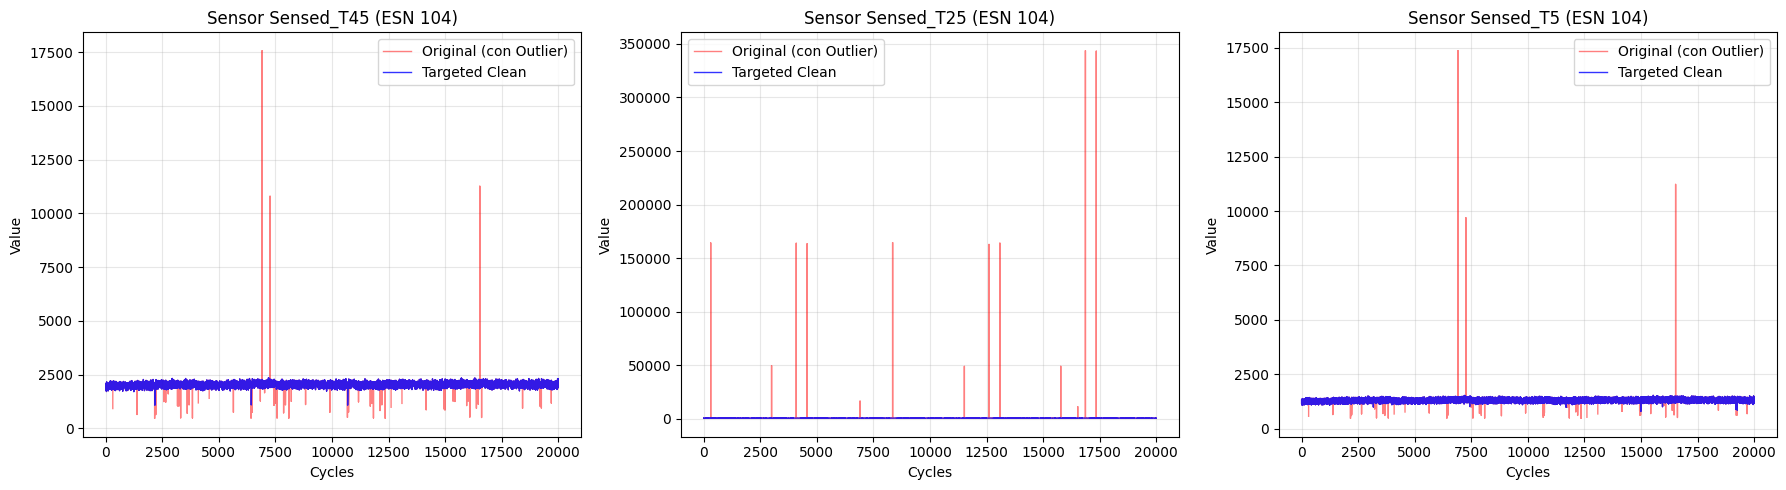

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

# Leggi la config
config_path = Path('../configs/config.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

train_csv_path = Path('../') / config['data']['train_csv']

# Carica i dati
df = pd.read_csv(train_csv_path)
df = df.sort_values(by=['ESN', 'Cycles', 'Snapshot']).reset_index(drop=True)

sensor_cols = [col for col in df.columns if col.startswith('Sensed_')]

df_targeted = df.copy()

def targeted_outlier_removal(series, window=50, k=3):
    """
    Replaces only points that are more than k standard deviations 
    away from the rolling median.
    """
    # Fill NaNs temporarily for calculation
    temp_series = series.interpolate().bfill().ffill()
    
    # Calculate rolling median and rolling std
    rolling_median = temp_series.rolling(window=window, center=True, min_periods=1).median()
    rolling_std = temp_series.rolling(window=window, center=True, min_periods=1).std()
    
    # Identify outliers: where distance from median is > k * std
    is_outlier = (np.abs(temp_series - rolling_median) > (k * rolling_std))
    
    # Replace outliers with the rolling median, keep others original
    clean_series = series.copy()
    clean_series[is_outlier] = rolling_median[is_outlier]
    
    return clean_series

for col in sensor_cols:
    df_targeted[col] = df_targeted.groupby('ESN')[col].transform(lambda x: targeted_outlier_removal(x))

# Save the targeted cleaned dataset
#df_targeted.to_csv('targeted_cleaned_data.csv', index=False)

engine_ids = [101, 102, 103, 104]
sensor_to_plot = ['Sensed_T45', 'Sensed_T25','Sensed_T5']

for eid in engine_ids:
    orig = df[df['ESN'] == eid]
    clean = df_targeted[df_targeted['ESN'] == eid]
    cycles = orig['Cycles']

    fig, axes = plt.subplots(1, len(sensor_to_plot), figsize=(18, 5), sharex=True)
    
    for i, col in enumerate(sensor_to_plot):
        axes[i].plot(cycles, orig[col], label='Original (con Outlier)', alpha=0.5, color='red', linewidth=1)
        axes[i].plot(cycles, clean[col], label='Targeted Clean', alpha=0.8, color='blue', linewidth=1)
        axes[i].set_title(f'Sensor {col} (ESN {eid})')
        axes[i].set_xlabel('Cycles')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()